# Week 3 Studio — Soluciones

**Una función de búsqueda, cuatro algoritmos.**

Solución completa de las tres tareas del [`README.md`](README.md) de esta carpeta:

| Tarea | Contenido | Sección |
|---|---|---|
| **Tarea 1** | Formulación de *misioneros y caníbales* (los cinco componentes) | §2 |
| **Tarea 2** | `bfs`, `dfs`, `ucs`, `ids` sobre el mismo `search()` | §3 |
| **Tests** | Los 5 tests de `test_search.py`, ejecutados aquí | §4 |
| **Tarea 3** | Medición sobre el banco de 40 instancias + **gráfica log** | §5 |

Referencias usadas: [`slides/week-03/deck.md`](../../slides/week-03/deck.md) y
[`notebooks/week-03-uninformed-search.ipynb`](../../notebooks/week-03-uninformed-search.ipynb).

> `search.py` (el motor genérico), `instances.json` y `test_search.py` son **dados** y no
> se modifican. Este notebook solo aporta lo que el estudio pide escribir.

## 1 · Setup

`search.py` vive en esta misma carpeta. Lo agregamos al `sys.path` para que el notebook
funcione sin importar desde dónde se abra Jupyter.

In [1]:
import sys, time, math
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "search.py").exists():          # abierto desde la raiz del repo
    HERE = Path.cwd() / "studios" / "week-03"
sys.path.insert(0, str(HERE))

from search import (Problem, Node, Frontier, search,
                    EightPuzzle, TinyGraph, GOAL, show,
                    D2, D8, D12, D16, load_instances)

print("search.py cargado desde:", HERE)

search.py cargado desde: c:\Users\andyv\OneDrive - Universidad San Francisco de Quito\Documentos\USFQ\Noveno semestre\Inteligencia Artificial\Fork\cmp-4004-fall26\studios\week-03


## 2 · Tarea 1 — Formular misioneros y caníbales

Tres misioneros, tres caníbales, un bote que lleva **1 o 2** personas y **nunca cruza vacío**.
Si en *cualquiera* de las dos orillas los caníbales superan en número a los misioneros
—**incluida la orilla que el bote acaba de dejar**— los misioneros son devorados.

### Los cinco componentes (slide *Problem formulation*)

| Componente | Elección |
|---|---|
| **Estado** | `(m_izq, c_izq, bote)` — misioneros y caníbales en la orilla **izquierda**, `bote ∈ {0=izq, 1=der}` |
| **Estado inicial** | `(3, 3, 0)` |
| **Acciones** | `(m, c)` = pasajeros que suben al bote, con `1 ≤ m + c ≤ 2` |
| **Modelo de transición** | restar en la izquierda si el bote está a la izquierda, sumar si está a la derecha, y **voltear** el lado del bote |
| **Test de meta** | `estado == (0, 0, 1)` |
| **Costo** | 1 por travesía → el óptimo es el mínimo número de cruces |

### Por qué este estado y no otro

No guardamos *quién* es cada persona: los misioneros son intercambiables entre sí, y los
caníbales también. Contar en lugar de identificar colapsa un espacio de $2^6 \cdot 2$ asignaciones
a **32 estados** nominales — 20 legales, y solo **16 alcanzables** desde el inicio. Tampoco guardamos la orilla
derecha: es `3 - m_izq`, `3 - c_izq` — información redundante que solo duplicaría estados.
Es exactamente el argumento del slide *«mover la ficha» vs. «mover el blanco»* del 8-puzzle:
**mismo problema, factor de ramificación radicalmente distinto**.

La tupla es *hashable*, así que el `explored` de `search()` funciona sin trabajo adicional.

### La decisión de diseño que hay que defender

> ¿Se excluyen los estados ilegales en `actions()` o en `result()`?

**Elegimos `actions()`**: solo se generan los movimientos cuyo estado resultante es legal.
`result()` queda como una transición pura y total (aplica la acción, no juzga).

**Defensa** (esto es lo que se presenta en el demo):

1. **`result()` es el modelo de transición, no el árbitro de las reglas.** En los cinco
   componentes, qué es legal vive del lado de *Actions*; `Result(s, a) → s'` es una función
   determinista y total. Mezclar las dos responsabilidades rompe la interfaz que reutilizan
   las semanas 4 y 9 (A\* le pide a `result()` un estado, no un `None`).
2. **Podar en la generación es estrictamente más barato.** Un nodo ilegal que no se crea no se
   *hashea*, no entra a la frontera y no hay que sacarlo de ella. Lo medimos abajo: la variante
   que deja pasar los ilegales expande **más nodos para la misma solución**.
3. **El `search()` dado no tiene dónde rechazar.** No existe un gancho entre `result()` y el
   `frontier.push()`; si `result()` quisiera vetar, tendría que devolver un estado centinela —y
   eso es justamente la variante B que medimos abajo.

**El costo de esta elección** —y hay que reconocerlo— es que `actions()` deja de ser
declarativo: ahora llama a `result()` internamente, así que las reglas del dominio quedan
repartidas entre `actions()` y el predicado `_is_legal()`. La variante B es más honesta como
*modelo* (dice «este estado existe, pero es mortal») y por eso no es una respuesta incorrecta:
es otro punto de equilibrio entre claridad del modelo y costo de búsqueda.

In [2]:
class MissionariesAndCannibals(Problem):
    """Estado: (m_izq, c_izq, bote), con bote 0=izquierda, 1=derecha.

    Los estados ilegales se excluyen en ``actions()``: solo se ofrecen las cargas
    del bote cuyo estado resultante respeta la regla en AMBAS orillas.
    """

    def __init__(self, m=3, c=3, b=2):
        self.M, self.C, self.B = m, c, b       # misioneros, canibales, capacidad
        super().__init__(initial=(m, c, 0), goal=(0, 0, 1))

    # -- la regla del dominio, en un solo lugar ---------------------------
    def _is_legal(self, state):
        m_l, c_l, _ = state
        if not (0 <= m_l <= self.M and 0 <= c_l <= self.C):
            return False                       # conteos imposibles
        m_r, c_r = self.M - m_l, self.C - c_l
        if m_l and c_l > m_l:                  # orilla izquierda
            return False
        if m_r and c_r > m_r:                  # orilla derecha (la recien dejada incluida)
            return False
        return True

    # -- los cinco componentes -------------------------------------------
    def actions(self, state):
        """Cargas (m, c) legales: 1 <= m+c <= 2, disponibles en la orilla del bote,
        y cuyo estado resultante no viola la regla en ninguna de las dos orillas."""
        m_l, c_l, boat = state
        avail_m, avail_c = (m_l, c_l) if boat == 0 else (self.M - m_l, self.C - c_l)
        legal = []
        for m in range(min(self.B, avail_m) + 1):
            for c in range(min(self.B, avail_c) + 1):
                if 1 <= m + c <= self.B and self._is_legal(self.result(state, (m, c))):
                    legal.append((m, c))
        return legal

    def result(self, state, action):
        """Transicion pura: mueve la carga y voltea el bote. No juzga legalidad."""
        m_l, c_l, boat = state
        m, c = action
        direction = -1 if boat == 0 else +1    # sale de la izquierda / regresa a ella
        return (m_l + direction * m, c_l + direction * c, 1 - boat)

    def is_goal(self, state):
        return state == self.goal

    def step_cost(self, state, action):
        return 1                               # una travesia = un costo


mc = MissionariesAndCannibals()
print("inicial:", mc.initial, "   meta:", mc.goal)
print("acciones desde (3,3,0):", mc.actions(mc.initial), "\n")
print("las 5 cargas posibles del bote, una por una:")
for a in [(0, 1), (1, 0), (0, 2), (1, 1), (2, 0)]:
    s2 = mc.result(mc.initial, a)
    veredicto = "legal" if mc._is_legal(s2) else "ILEGAL -> se poda en actions()"
    print(f"   {a} -> {s2}   {veredicto}")

inicial: (3, 3, 0)    meta: (0, 0, 1)
acciones desde (3,3,0): [(0, 1), (0, 2), (1, 1)] 

las 5 cargas posibles del bote, una por una:
   (0, 1) -> (3, 2, 1)   legal
   (1, 0) -> (2, 3, 1)   ILEGAL -> se poda en actions()
   (0, 2) -> (3, 1, 1)   legal
   (1, 1) -> (2, 2, 1)   legal
   (2, 0) -> (1, 3, 1)   ILEGAL -> se poda en actions()


### El espacio de estados completo

32 estados nominales, 20 legales, 16 alcanzables desde `(3,3,0)`. Es pequeño a propósito: se
puede dibujar en la pizarra, que es lo que hace posible el debate sobre la formulación.

In [3]:
todos   = [(m, c, b) for m in range(4) for c in range(4) for b in (0, 1)]
legales = [s for s in todos if mc._is_legal(s)]

# alcanzables: recorrido sobre el grafo de estados desde (3,3,0)
vistos, pila = {mc.initial}, [mc.initial]
while pila:
    s = pila.pop()
    for a in mc.actions(s):
        t = mc.result(s, a)
        if t not in vistos:
            vistos.add(t)
            pila.append(t)

print(f"estados nominales        : {len(todos)}")
print(f"estados legales          : {len(legales)}")
print(f"alcanzables desde (3,3,0): {len(vistos)}")
print(f"factor de ramificacion medio: "
      f"{sum(len(mc.actions(s)) for s in vistos) / len(vistos):.2f}")

estados nominales        : 32
estados legales          : 20
alcanzables desde (3,3,0): 16
factor de ramificacion medio: 2.12


### Resolverlo (adelanto de la Tarea 2)

Once travesías es el óptimo conocido del rompecabezas. Lo imprimimos legible para poder
**verificar la formulación a mano**: cada línea debe dejar las dos orillas en un estado legal.

In [4]:
def mostrar_plan(problem, node):
    """Imprime el plan como tabla de orillas: verificacion manual de la formulacion."""
    print(f"  {'#':>2}  {'accion':^10}  {'izquierda':>12}  {'bote':^12}  {'derecha':<12}")
    print("  " + "-" * 60)

    def fila(i, etiqueta, s):
        m_l, c_l, b = s
        izq = "M" * m_l + "C" * c_l or "-"
        der = "M" * (problem.M - m_l) + "C" * (problem.C - c_l) or "-"
        bote = "<bote  ~~~~~" if b == 0 else "~~~~~  bote>"
        print(f"  {i:>2}  {etiqueta:^10}  {izq:>12}  {bote:^12}  {der:<12}")

    s = problem.initial
    fila(0, "inicio", s)
    for i, a in enumerate(node.path(), 1):
        s = problem.result(s, a)
        fila(i, f"{a[0]}M+{a[1]}C", s)
    print(f"\n  {len(node.path())} travesias, costo g = {node.g}")

## 3 · Tarea 2 — Los cuatro algoritmos

> **BFS, DFS y UCS son el *mismo* bucle `search()` con una disciplina de frontera distinta.**
> Esa es la idea de la semana, y por eso tres de las cuatro funciones son de una línea.

| Algoritmo | `frontier_kind` | ¿Completo? | ¿Óptimo? | Tiempo | Espacio |
|---|---|---|---|---|---|
| BFS | `"fifo"` | Sí | **solo** con costos uniformes | O(bᵈ) | O(bᵈ) |
| DFS | `"lifo"` | espacios finitos con control de ciclos | No | O(bᵐ) | O(b·m) |
| UCS | `"priority"` | Sí | **Sí** (costos no negativos) | O(b^(1+⌊C\*/ε⌋)) | igual |
| IDS | DFS limitado, iterado | Sí | solo con costos uniformes | O(bᵈ) | **O(b·d)** |

Nótese la disciplina de enunciar la garantía **junto con su condición**: «BFS es óptimo» a secas
vale cero (slide *Four evaluation criteria*).

In [5]:
def bfs(problem):
    """Breadth-first search: frontera FIFO -> expande primero lo mas superficial.

    Completo. Optimo SOLO si todos los pasos cuestan lo mismo: cuenta aristas, no costo.
    Espacio O(b^d) -- la memoria, no el tiempo, es lo que mata a BFS.
    """
    return search(problem, "fifo")


def dfs(problem):
    """Depth-first (graph) search: frontera LIFO -> expande primero lo mas profundo.

    No es optimo. Termina en grafos ciclicos SOLO gracias al `explored` de search():
    sin el, el arbol de busqueda de un grafo con un ciclo es infinito.
    """
    return search(problem, "lifo")


def ucs(problem):
    """Uniform-cost search: cola de prioridad ordenada por g(n).

    Optimo para cualquier costo de paso no negativo -- y por eso el test de meta
    de search() ocurre en la EXPANSION, no en la generacion.
    """
    return search(problem, "priority")

### IDS — el interesante

`ids` **no** usa `search()`: hace búsqueda en **árbol** con límite de profundidad y va subiendo el
límite. Con eso compra la completitud de BFS al costo de memoria de DFS, **O(b·d)**, pagando con
trabajo repetido.

`depth_limited` devuelve `(node, expansions, hit_limit)`. La bandera `hit_limit` distingue
*«no encontré la meta, pero corté por el límite»* (sirve seguir profundizando) de
*«agoté el subárbol»* (no hay solución, deja de iterar).

La única defensa contra ciclos es saltar el **estado padre inmediato**: evita los 2-ciclos
`arriba→abajo` a costo cero de memoria. No es un `explored` —eso arruinaría el O(b·d)—, así que
IDS sí revisita estados que BFS almacenaría. Ese es el precio del ahorro de memoria.

In [6]:
def depth_limited(problem, limit):
    """DFS recursivo hasta profundidad `limit`. Devuelve (node, expansions, hit_limit).

    hit_limit=True  <=> la busqueda fue CORTADA por el limite (puede haber meta mas abajo)
    hit_limit=False <=> el subarbol se agoto por completo (profundizar mas no ayuda)
    """
    expansions = [0]

    def recurse(node, depth):
        if problem.is_goal(node.state):
            return node, False
        if depth == 0:
            return None, True                      # cortado por el limite
        expansions[0] += 1                         # se cuenta al EXPANDIR
        cutoff = False
        for action in problem.actions(node.state):
            child_state = problem.result(node.state, action)
            # saltar el padre inmediato: evita 2-ciclos sin costo de memoria
            if node.parent is not None and child_state == node.parent.state:
                continue
            cost = problem.step_cost(node.state, action)
            child = Node(child_state, node, action, node.g + cost)
            result, hit = recurse(child, depth - 1)
            if result is not None:
                return result, False
            cutoff = cutoff or hit
        return None, cutoff

    node, hit_limit = recurse(Node(problem.initial), limit)
    return node, expansions[0], hit_limit


def ids(problem, max_depth=40):
    """Iterative deepening: limite = 0, 1, 2, ... hasta encontrar la meta.

    Devuelve (node, expansiones_totales). Si un nivel NO fue cortado y no hallo nada,
    el espacio se agoto -> (None, total).
    """
    total = 0
    for limit in range(max_depth + 1):
        node, expansions, hit_limit = depth_limited(problem, limit)
        total += expansions
        if node is not None:
            return node, total
        if not hit_limit:
            return None, total                     # espacio agotado: no hay solucion
    return None, total                             # se acabo el presupuesto max_depth


ALGOS = [("BFS", bfs), ("DFS", dfs), ("UCS", ucs), ("IDS", ids)]

### Los cuatro sobre misioneros y caníbales

Primero el plan óptimo, luego la comparación. Obsérvese que **DFS también resuelve este problema
en 11 travesías**: no porque sea óptimo, sino porque el espacio es tan estrecho (16 estados
alcanzables, ramificación media ≈ 2.1) que casi cualquier camino hasta la meta es corto. En el
8-puzzle, con un espacio grande, DFS queda al descubierto.

In [7]:
node, exp = bfs(mc)
mostrar_plan(mc, node)

print()
print(f"  {'algoritmo':<10}{'expansiones':>13}{'travesias':>12}{'costo g':>10}")
print("  " + "-" * 45)
for name, algo in ALGOS:
    n, e = algo(MissionariesAndCannibals())
    print(f"  {name:<10}{e:>13,}{len(n.path()):>12}{n.g:>10}")

   #    accion       izquierda      bote      derecha     
  ------------------------------------------------------------
   0    inicio          MMMCCC  <bote  ~~~~~  -           
   1    0M+2C             MMMC  ~~~~~  bote>  CC          
   2    0M+1C            MMMCC  <bote  ~~~~~  C           
   3    0M+2C              MMM  ~~~~~  bote>  CCC         
   4    0M+1C             MMMC  <bote  ~~~~~  CC          
   5    2M+0C               MC  ~~~~~  bote>  MMCC        
   6    1M+1C             MMCC  <bote  ~~~~~  MC          
   7    2M+0C               CC  ~~~~~  bote>  MMMC        
   8    0M+1C              CCC  <bote  ~~~~~  MMM         
   9    0M+2C                C  ~~~~~  bote>  MMMCC       
  10    0M+1C               CC  <bote  ~~~~~  MMMC        
  11    0M+2C                -  ~~~~~  bote>  MMMCCC      

  11 travesias, costo g = 11

  algoritmo   expansiones   travesias   costo g
  ---------------------------------------------
  BFS                  14          11      

### La variante B: filtrar en `result()` (la postura contraria)

Para que la defensa del demo no sea retórica, implementamos **también** la otra opción y la
medimos. Como `search()` no ofrece ningún gancho para rechazar un hijo, la única forma de «vetar
desde `result()`» es mapear los estados ilegales a un estado absorbente `DEAD` sin acciones: se
genera, se *hashea*, entra a la frontera, se expande… y muere ahí.

A cambio, `actions()` queda declarativo (*«el bote lleva 1 o 2 personas»*, y nada más), que es su
ventaja real.

In [8]:
DEAD = "DEAD"          # estado absorbente: existe, pero no lleva a ninguna parte


class MissionariesAndCannibalsB(MissionariesAndCannibals):
    """Variante B: `actions()` solo conoce la capacidad del bote; la regla de los
    canibales la aplica `result()`, mandando los estados mortales a DEAD."""

    def actions(self, state):
        if state == DEAD:
            return []                                   # callejon sin salida
        m_l, c_l, boat = state
        avail_m, avail_c = (m_l, c_l) if boat == 0 else (self.M - m_l, self.C - c_l)
        return [(m, c)
                for m in range(min(self.B, avail_m) + 1)
                for c in range(min(self.B, avail_c) + 1)
                if 1 <= m + c <= self.B]

    def result(self, state, action):
        s2 = super().result(state, action)
        return s2 if self._is_legal(s2) else DEAD       # aqui se aplica la regla


print(f"  {'variante / algoritmo':<36}{'expansiones':>13}{'travesias':>12}")
print("  " + "-" * 61)
for etiqueta, cls in [("A - poda en actions()", MissionariesAndCannibals),
                      ("B - filtra en result() via DEAD", MissionariesAndCannibalsB)]:
    for name, algo in ALGOS:
        n, e = algo(cls())
        print(f"  {etiqueta + ' / ' + name:<36}{e:>13,}{len(n.path()):>12}")
    print()

print("Misma solucion optima (11 travesias) en ambas: las dos formulaciones son correctas.")
print("La diferencia es cuanto trabajo cuesta encontrarla -- ese es el argumento del demo.")

  variante / algoritmo                  expansiones   travesias
  -------------------------------------------------------------
  A - poda en actions() / BFS                    14          11
  A - poda en actions() / DFS                    11          11
  A - poda en actions() / UCS                    14          11
  A - poda en actions() / IDS                   201          11

  B - filtra en result() via DEAD / BFS           15          11
  B - filtra en result() via DEAD / DFS           12          11
  B - filtra en result() via DEAD / UCS           15          11
  B - filtra en result() via DEAD / IDS          385          11

Misma solucion optima (11 travesias) en ambas: las dos formulaciones son correctas.
La diferencia es cuanto trabajo cuesta encontrarla -- ese es el argumento del demo.


## 4 · Los tests provistos

`test_search.py` importa `starter` y llama `s.bfs`, `s.dfs`, `s.ucs`, `s.ids`. Aquí reapuntamos
ese nombre a las implementaciones de este notebook y corremos **los cinco tests originales, sin
tocar el archivo**.

El que hay que leer con atención es `test_bfs_suboptimal_nonuniform_cost`: **afirma que BFS
devuelve la respuesta incorrecta** (costo 10 en vez de 2) sobre `TinyGraph`. No es un test roto.
BFS cuenta aristas, no costo; su garantía de optimalidad tiene una condición —costos uniformes—
y esta instancia la viola a propósito. *Una garantía que nunca viste fallar es una garantía que
no entendiste.*

In [9]:
import types
import test_search

test_search.s = types.SimpleNamespace(
    bfs=bfs, dfs=dfs, ucs=ucs, ids=ids,
    depth_limited=depth_limited,
    MissionariesAndCannibals=MissionariesAndCannibals,
)

fallos = 0
for t in test_search.TESTS:
    try:
        t()
    except AssertionError as e:
        print(f"  FAIL {t.__name__}: {e}")
        fallos += 1

total = len(test_search.TESTS)
print(f"\n{total - fallos}/{total} tests pasan" + ("" if fallos else "  -- todos"))

  ok  bfs optimal on uniform costs (len=8)
  ok  bfs suboptimal on non-uniform costs (g=10 > optimum 2 -- the lesson)
  ok  dfs terminates on a cyclic graph (explored set does its job)
  ok  ucs optimal on non-uniform costs (g=2)
  ok  ids matches bfs solution length (8) at O(bd) memory

5/5 tests pasan  -- todos


### Ver fallar la garantía, de cerca

BFS y UCS sobre el *mismo* grafo de 3 nodos: `start→A` cuesta 10, `start→B→A` cuesta 2. Es el
contraejemplo del notebook 3A y la razón por la que UCS existe.

In [10]:
tg = TinyGraph("start", "A")
for name, algo in [("BFS", bfs), ("UCS", ucs)]:
    n, e = algo(tg)
    veredicto = ("OPTIMO" if n.g == 2 else
                 "NO optimo (no se cumple la condicion de costos uniformes)")
    print(f"  {name}: camino={n.path()}  aristas={len(n.path())}  costo g={n.g}   <- {veredicto}")

  BFS: camino=['A']  aristas=1  costo g=10   <- NO optimo (no se cumple la condicion de costos uniformes)
  UCS: camino=['B', 'A']  aristas=2  costo g=2   <- OPTIMO


## 5 · Tarea 3 — Medir

40 instancias del 8-puzzle: 10 en cada profundidad óptima 4, 8, 12 y 16 (semilla 20260807,
profundidades verificadas por BFS exhaustivo). Los cuatro algoritmos sobre cada una.

**Instrumentar desde la primera línea.** `expansions` no es decoración: es la única moneda en la
que estos cuatro se pueden comparar. A eso le agregamos el **pico de la frontera** —la memoria,
que es la restricción que de verdad muerde— y el tiempo de reloj.

Para el pico de frontera no se modifica `search.py` (es archivo dado): se usa una copia
instrumentada, idéntica línea por línea salvo por la medición.

In [11]:
def search_instrumented(problem, frontier_kind):
    """Copia EXACTA de search() mas la medicion del pico de la frontera.

    Devuelve (node, expansions, max_frontier). No sustituye a search(): sirve para
    ver el O(b^d) de BFS/UCS contra el O(b*m) de DFS con datos propios.
    """
    start = Node(problem.initial)
    if problem.is_goal(start.state):
        return start, 0, 0
    frontier = Frontier(frontier_kind)
    frontier.push(start)
    explored, expansions, peak = set(), 0, 1
    while frontier:
        peak = max(peak, len(frontier))
        node = frontier.pop()
        if problem.is_goal(node.state):
            return node, expansions, peak
        if node.state in explored:
            continue
        explored.add(node.state)
        expansions += 1
        for action in problem.actions(node.state):
            child_state = problem.result(node.state, action)
            if child_state not in explored:
                cost = problem.step_cost(node.state, action)
                frontier.push(Node(child_state, node, action, node.g + cost))
    return None, expansions, peak


def ids_peak(problem, max_depth=40):
    """Memoria de IDS = profundidad de la pila de recursion, acotada por el limite
    que finalmente tuvo exito. O(b*d), no O(b^d)."""
    total = 0
    for limit in range(max_depth + 1):
        node, expansions, hit = depth_limited(problem, limit)
        total += expansions
        if node is not None:
            return node, total, max(limit, 1)      # pila maxima = limite alcanzado
        if not hit:
            return None, total, max(limit, 1)
    return None, total, max_depth

In [12]:
KINDS = {"BFS": "fifo", "DFS": "lifo", "UCS": "priority"}


def measure(bank=None):
    """Corre los cuatro algoritmos sobre el banco. Devuelve filas
    (depth, algoritmo, expansiones, longitud_solucion, pico_memoria, segundos)."""
    bank = bank or load_instances()
    rows = []
    for depth in sorted(bank):
        for state in bank[depth]:
            p = EightPuzzle(state)
            for name, _ in ALGOS:
                t0 = time.perf_counter()
                if name == "IDS":
                    node, exp, peak = ids_peak(p)
                else:
                    node, exp, peak = search_instrumented(p, KINDS[name])
                rows.append((depth, name, exp, len(node.path()), peak,
                             time.perf_counter() - t0))
    return rows


bank = load_instances()
print("banco:", {d: len(v) for d, v in sorted(bank.items())}, "instancias por profundidad\n")
t0 = time.perf_counter()
rows = measure(bank)
print(f"{len(rows)} corridas en {time.perf_counter() - t0:.1f} s")

banco: {4: 10, 8: 10, 12: 10, 16: 10} instancias por profundidad

160 corridas en 6.5 s


### La tabla

Promedios por profundidad (10 instancias cada una). `longitud` es la longitud de la solución
devuelta: si no coincide con la profundidad óptima `d`, ese algoritmo **no** fue óptimo ahí.

In [13]:
NOMBRES = [n for n, _ in ALGOS]
depths = sorted({r[0] for r in rows})


def promedio(depth, algo, col):
    vals = [r[col] for r in rows if r[0] == depth and r[1] == algo]
    return sum(vals) / len(vals)


print(f"{'d':>3}  {'algoritmo':<6}{'expansiones':>13}{'longitud':>10}{'optimo?':>9}"
      f"{'memoria pico':>15}{'seg':>9}")
print("-" * 66)
for d in depths:
    for name in NOMBRES:
        leng = promedio(d, name, 3)
        ok = "si" if abs(leng - d) < 1e-9 else "NO"
        print(f"{d:>3}  {name:<6}{promedio(d, name, 2):>13,.0f}{leng:>10.1f}{ok:>9}"
              f"{promedio(d, name, 4):>15,.0f}{promedio(d, name, 5):>9.3f}")
    print()

  d  algoritmo  expansiones  longitud  optimo?   memoria pico      seg
------------------------------------------------------------------
  4  BFS              25       4.0       si             19    0.000
  4  DFS          12,489    9646.8       NO          7,372    0.046
  4  UCS              25       4.0       si             19    0.001
  4  IDS              23       4.0       si              4    0.000

  8  BFS             238       8.0       si            159    0.001
  8  DFS          37,578   33406.2       NO         26,292    0.146
  8  UCS             238       8.0       si            159    0.005
  8  IDS             330       8.0       si              8    0.001

 12  BFS           1,507      12.0       si            961    0.005
 12  DFS          37,701   36378.4       NO         28,991    0.146
 12  UCS           1,507      12.0       si            961    0.010
 12  IDS           2,789      12.0       si             12    0.006

 16  BFS           9,401      16.0       si

**Cómo se lee esta tabla en voz alta:**

- **BFS y UCS coinciden exactamente**, expansión por expansión. Todos los movimientos del
  8-puzzle cuestan 1, así que la cola de prioridad ordenada por `g` degenera en una FIFO. En
  `TinyGraph` no coincidirían — y esa diferencia *es* la razón de ser de UCS.
- **DFS no es óptimo, y la tabla es brutal al respecto.** Para una instancia de profundidad
  óptima **4** devuelve soluciones de **miles de movimientos**, y expande cientos de veces más
  nodos que BFS para lograrlo. Pierde en las dos cosas a la vez. La optimalidad no es un lujo
  que se estime a ojo.
- **El costo de DFS ni siquiera depende de `d`.** Su fila es plana —y hasta *baja* de d=8 a
  d=16—: DFS se lanza por una rama arbitraria hasta el fondo, así que lo que mide su columna es
  dónde cayó su zambullida, no qué tan difícil era la instancia. Un algoritmo cuyo costo no
  correlaciona con la dificultad del problema es un algoritmo que no está usando el problema.
- **IDS sigue de cerca a BFS en expansiones** (factor pequeño, no exponencial) con una pila
  proporcional a `d` en lugar de una frontera proporcional a `bᵈ`. Compárese la columna
  *memoria pico*: 16 contra 5,605 nodos en `d=16`. Ese es el intercambio de la semana, con
  datos propios.

### La gráfica — expansiones vs. profundidad, eje **y logarítmico**

Este es *el* entregable. **Rectas en un eje logarítmico significan crecimiento exponencial.**

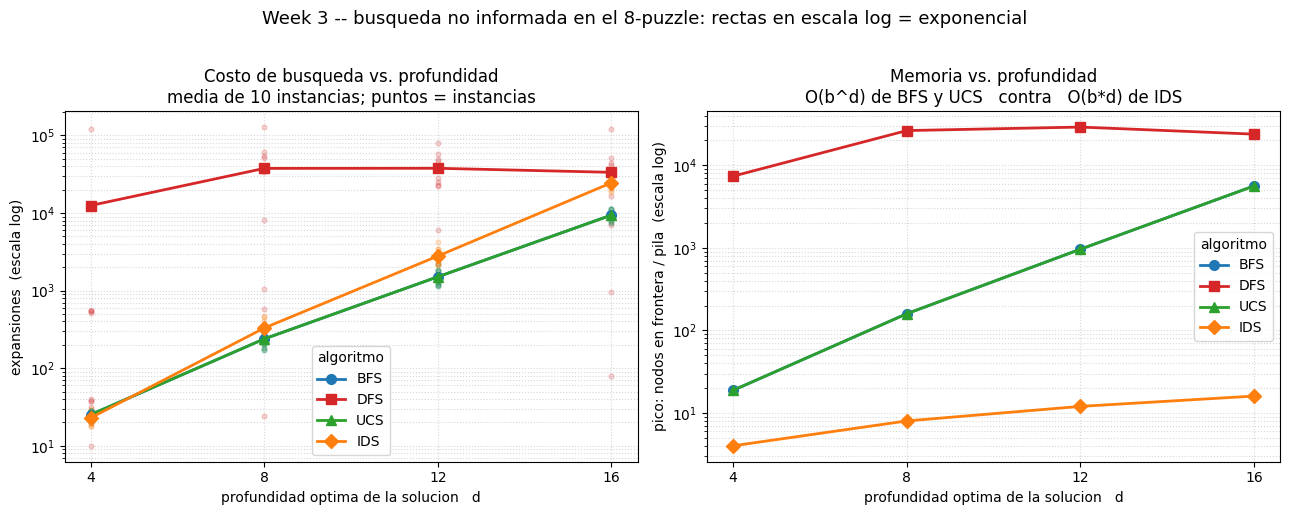

In [14]:
import matplotlib.pyplot as plt

COLORES = {"BFS": "#1f77b4", "DFS": "#d62728", "UCS": "#2ca02c", "IDS": "#ff7f0e"}
MARCAS = {"BFS": "o", "DFS": "s", "UCS": "^", "IDS": "D"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- izquierda: expansiones (log y) ---------------------------------------
for name in NOMBRES:
    ax1.scatter([r[0] for r in rows if r[1] == name],          # instancias sueltas
                [r[2] for r in rows if r[1] == name],
                color=COLORES[name], s=12, alpha=.20)
    ax1.plot(depths, [promedio(d, name, 2) for d in depths],   # media
             marker=MARCAS[name], color=COLORES[name], label=name, lw=2, ms=7)

ax1.set_yscale("log")
ax1.set_xlabel("profundidad optima de la solucion   d")
ax1.set_ylabel("expansiones  (escala log)")
ax1.set_title("Costo de busqueda vs. profundidad\nmedia de 10 instancias; puntos = instancias")
ax1.set_xticks(depths)
ax1.grid(True, which="both", ls=":", alpha=.5)
ax1.legend(title="algoritmo")

# --- derecha: memoria (log y) ---------------------------------------------
for name in NOMBRES:
    ax2.plot(depths, [promedio(d, name, 4) for d in depths],
             marker=MARCAS[name], color=COLORES[name], label=name, lw=2, ms=7)
ax2.set_yscale("log")
ax2.set_xlabel("profundidad optima de la solucion   d")
ax2.set_ylabel("pico: nodos en frontera / pila  (escala log)")
ax2.set_title("Memoria vs. profundidad\nO(b^d) de BFS y UCS   contra   O(b*d) de IDS")
ax2.set_xticks(depths)
ax2.grid(True, which="both", ls=":", alpha=.5)
ax2.legend(title="algoritmo")

fig.suptitle("Week 3 -- busqueda no informada en el 8-puzzle: rectas en escala log = exponencial",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### ¿Qué tan exponencial? El factor de ramificación efectivo

Si `expansiones ≈ A · b_ef^d`, entonces `ln(expansiones)` es una recta en `d` cuya pendiente es
`ln(b_ef)`. Ajustamos esa recta por mínimos cuadrados y usamos `b_ef` para responder la pregunta
del demo: **extrapola a profundidad 24 — ¿alcanza tu laptop?**

Hay que responderla con honestidad, porque **la extrapolación cruda no es toda la historia**:
el 8-puzzle tiene un techo duro de 181,440 estados alcanzables, y `search()` nunca expande un
estado dos veces. La curva exponencial choca contra ese techo y se aplana. La pregunta del demo
se contesta de verdad quitando el techo — es decir, cambiando de dominio.

In [15]:
def ajuste_exponencial(name):
    """Regresion lineal de ln(expansiones) sobre d -> (b_efectivo, A)."""
    xs = depths
    ys = [math.log(promedio(d, name, 2)) for d in xs]
    n = len(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    pend = (sum((x - mx) * (y - my) for x, y in zip(xs, ys))
            / sum((x - mx) ** 2 for x in xs))
    return math.exp(pend), math.exp(my - pend * mx)


seg_por_exp = sum(r[5] for r in rows) / sum(r[2] for r in rows)
BYTES_NODO = 120                    # Node con __slots__ + entrada en set/heap, aprox.
ESTADOS_8P = 181_440                # techo duro: estados alcanzables del 8-puzzle


def humano_tiempo(segs):
    for div, u in [(1, "s"), (60, "min"), (3600, "h"), (86400, "dias"), (86400 * 365, "anos")]:
        if segs / div < 1000:
            return f"{segs / div:,.1f} {u}"
    return f"{segs / (86400 * 365):,.0f} anos"


def humano_bytes(b):
    for div, u in [(1, "B"), (2**10, "KB"), (2**20, "MB"), (2**30, "GB"), (2**40, "TB")]:
        if b / div < 1024:
            return f"{b / div:,.1f} {u}"
    return f"{b / 2**50:,.1f} PB"


print(f"medido en esta maquina: {seg_por_exp * 1e6:.2f} microsegundos por expansion")
print(f"techo del dominio     : {ESTADOS_8P:,} estados alcanzables\n")

print("8-PUZZLE -- ajuste sobre d = 4, 8, 12, 16 y extrapolacion a d = 24")
print(f"{'algoritmo':<6}{'b_efectivo':>12}{'exp. @ d=16':>14}{'extrap. @ d=24':>17}"
      f"{'con techo':>13}{'tiempo':>12}{'memoria':>12}")
print("-" * 86)
for name in NOMBRES:
    b, A = ajuste_exponencial(name)
    crudo = A * b ** 24
    # BFS/DFS/UCS son busqueda en GRAFO: el explored les impone el techo del dominio.
    # IDS es busqueda en ARBOL: revisita estados, asi que el techo no lo acota.
    real = crudo if name == "IDS" else min(crudo, ESTADOS_8P)
    mem = (24 * BYTES_NODO if name == "IDS"         # O(b*d): la pila de recursion
           else real * BYTES_NODO)                  # O(b^d): la frontera
    print(f"{name:<6}{b:>12.2f}{promedio(16, name, 2):>14,.0f}{crudo:>17,.0f}"
          f"{real:>13,.0f}{humano_tiempo(real * seg_por_exp):>12}{humano_bytes(mem):>12}")

print("""
Honestidad primero: en el 8-PUZZLE la laptop SI alcanza a d=24, y no porque BFS sea
barato, sino porque el dominio es diminuto. La exponencial choca contra el techo de
181,440 estados y se aplana. (La fila de DFS, con b_ef ~ 1.1, no significa nada: su
costo no depende de d, ya lo vimos en la tabla anterior.)

Ahora quitemos el techo -- misma exponencial, dominio sin tope alcanzable:""")

# 15-puzzle: mismo algoritmo, mismo codigo, un tablero mas grande
ESTADOS_15P = 10_461_394_944_000        # 16!/2
B_15, D_15 = 2.13, 52                   # ramificacion efectiva y profundidad tipica
crudo15 = B_15 ** D_15
real15 = min(crudo15, ESTADOS_15P)      # otra vez, acotado por el dominio

print(f"\n15-PUZZLE   estados alcanzables : {ESTADOS_15P:,.0f}  (~10^13)")
print(f"            b_efectivo ~ {B_15}, profundidad tipica d ~ {D_15}")
print(f"            b^d crudo            : {crudo15:,.3g}")
print(f"            expansiones (con techo): {real15:,.0f}")
print(f"            tiempo a {seg_por_exp * 1e6:.1f} us/exp : {humano_tiempo(real15 * seg_por_exp)}")
print(f"            memoria de la frontera : {humano_bytes(real15 * BYTES_NODO)}")

print("""
Respuesta a la pregunta del demo: NO, la laptop no alcanza.
El mismo codigo, sobre un tablero de 4x4, pide mas de un ANO de CPU y una frontera de
~1 PB. Y notese cual de los dos numeros manda: un ano se puede esperar, un petabyte de
RAM no se puede comprar. Se muere por MEMORIA antes que por tiempo -- exactamente lo
que anuncia la columna Space de la tabla de la semana. Ademas b^d no se arregla con
hardware: duplicar la RAM compra ~0.9 niveles mas de profundidad, una sola vez.

La unica salida es dejar de buscar a ciegas -- darle a la busqueda informacion sobre
que estados son prometedores. Eso es exactamente la semana 4: A* como un diff de
10 lineas sobre este mismo search().""")

medido en esta maquina: 3.79 microsegundos por expansion
techo del dominio     : 181,440 estados alcanzables

8-PUZZLE -- ajuste sobre d = 4, 8, 12, 16 y extrapolacion a d = 24
algoritmo  b_efectivo   exp. @ d=16   extrap. @ d=24    con techo      tiempo     memoria
--------------------------------------------------------------------------------------
BFS           1.63         9,401          516,552      181,440       0.7 s     20.8 MB
DFS           1.08        33,434           78,080       78,080       0.3 s      8.9 MB
UCS           1.63         9,401          516,552      181,440       0.7 s     20.8 MB
IDS           1.78        24,520        2,716,422    2,716,422      10.3 s      2.8 KB

Honestidad primero: en el 8-PUZZLE la laptop SI alcanza a d=24, y no porque BFS sea
barato, sino porque el dominio es diminuto. La exponencial choca contra el techo de
181,440 estados y se aplana. (La fila de DFS, con b_ef ~ 1.1, no significa nada: su
costo no depende de d, ya lo vimos en la tabl

### El sobrecosto de IDS es un factor **constante**

La afirmación del slide es que rehacer el trabajo superficial cuesta un **factor constante**, no
uno exponencial, porque el nivel más profundo domina la suma. Para comprobarla con datos hay que
separar **dos efectos distintos** que la razón `IDS/BFS` mezcla, y que confundirlos es la trampa
de esta medición:

1. **El sobrecosto del *deepening*** — rehacer las capas superficiales. Es la suma geométrica
   `Σ bⁱ / bᵈ`, cuyo límite es `b/(b−1)`. **Constante**, y es lo único que la afirmación promete.
2. **La diferencia árbol vs. grafo** — IDS solo salta al padre inmediato, así que revisita
   estados que el `explored` de BFS deduplica. Este efecto **sí** crece con `d`, y no tiene nada
   que ver con el deepening.

#### 1. El sobrecosto del *deepening*, aislado

Hay que medirlo con el test de meta **desactivado**: si la última iteración se detiene al
encontrar la meta —normalmente a media capa— el denominador queda truncado y el cociente sale
inflado. Con un 8-puzzle sin meta, `depth_limited(p, L)` expande la capa `L` completa, y entonces
`Σ_{i≤L} E_i / E_L` es exactamente la suma geométrica del slide.

In [16]:
class OchoPuzzleSinMeta(EightPuzzle):
    """Identico al 8-puzzle, pero is_goal() nunca es verdadero: fuerza a
    depth_limited a agotar cada capa completa. Solo sirve para medir."""

    def is_goal(self, state):
        return False


p_medida = OchoPuzzleSinMeta(D16)
acumulado, filas = 0, []
for limite in range(15):
    _, exp, _ = depth_limited(p_medida, limite)
    nivel = exp - acumulado           # expansiones que aporta ESTA capa
    acumulado = exp
    filas.append((limite, nivel, exp))

print(f"{'limite L':>9}{'capa L sola':>14}{'suma 0..L':>13}{'suma/capa':>12}{'b local':>10}")
print("-" * 58)
prev = None
for L, nivel, total in filas[2:]:
    b_local = nivel / prev if prev else float("nan")
    print(f"{L:>9}{nivel:>14,}{total:>13,}{total / nivel:>11.2f}x{b_local:>10.2f}")
    prev = nivel

# 'b local' oscila por PARIDAD: el blanco alterna entre casillas con 2, 3 y 4 vecinos,
# asi que una capa se ensancha y la siguiente casi no. El b real se toma cada DOS capas.
b_lim = math.sqrt(filas[-1][1] / filas[-3][1])
observado = [t / n for _, n, t in filas[-6:]]
media = sum(observado) / len(observado)

print(f"""
La columna 'suma/capa' NO crece con L: oscila alrededor de {media:.2f}x y ahi se queda.
Ese es el sobrecosto real del deepening, y es CONSTANTE -- que es exactamente lo unico
que la afirmacion del slide promete.

La oscilacion no es ruido: es PARIDAD. El blanco del 8-puzzle alterna entre casillas de
2, 3 y 4 vecinos, asi que una capa se ensancha y la siguiente casi no ('b local' salta
entre 2.00 y ~1.3). Por eso el b efectivo se mide cada DOS capas: b = {b_lim:.2f}, y la
prediccion teorica b/(b-1) = {b_lim / (b_lim - 1):.2f}x -- que es lo que observamos.

Y aqui esta el matiz que el 11% del libro esconde: 11% es b/(b-1) evaluado en b=10.
No es una constante universal, es una FUNCION de b. Con el b~1.8 del 8-puzzle el
sobrecosto ronda 2.3x, no 1.11x. Sigue siendo constante; simplemente es una constante
mas grande, porque un arbol angosto guarda menos de su masa en la ultima capa.""")

 limite L   capa L sola    suma 0..L   suma/capa   b local
----------------------------------------------------------
        2             4            5       1.25x       nan
        3             8           13       1.62x      2.00
        4             8           21       2.62x      1.00
        5            16           37       2.31x      2.00
        6            32           69       2.16x      2.00
        7            64          133       2.08x      2.00
        8            80          213       2.66x      1.25
        9           160          373       2.33x      2.00
       10           272          645       2.37x      1.70
       11           544        1,189       2.19x      2.00
       12           752        1,941       2.58x      1.38
       13         1,504        3,445       2.29x      2.00
       14         2,384        5,829       2.45x      1.59

La columna 'suma/capa' NO crece con L: oscila alrededor de 2.37x y ahi se queda.
Ese es el sobrecosto real del dee

#### 2. La razón `IDS / BFS`, y por qué **sí** crece

Esta es la comparación que sí importa en la práctica, y crece con `d` — pero **no** por el
deepening, que acabamos de ver acotado. Crece porque IDS busca en **árbol** y BFS en **grafo**:
IDS revisita estados que el `explored` de BFS deduplica. Ese es el precio honesto de no guardar
`explored` — que es exactamente lo que compra el O(b·d).

In [17]:
print(f"{'d':>3}{'BFS exp':>12}{'IDS exp':>12}{'IDS/BFS':>10}"
      f"{'BFS frontera':>15}{'IDS pila':>11}{'ahorro mem.':>14}")
print("-" * 77)
for d in depths:
    b_exp, i_exp = promedio(d, "BFS", 2), promedio(d, "IDS", 2)
    b_mem, i_mem = promedio(d, "BFS", 4), promedio(d, "IDS", 4)
    print(f"{d:>3}{b_exp:>12,.0f}{i_exp:>12,.0f}{i_exp / b_exp:>9.2f}x"
          f"{b_mem:>15,.0f}{i_mem:>11,.0f}{b_mem / i_mem:>13.0f}x")

print("""
El trato, en una linea: a d=16, IDS paga 2.6x en expansiones y cobra 350x en memoria.

Mientras BFS quepa en RAM, ese trato no vale la pena. En cuanto no quepa -- y con b^d
eso llega rapido -- deja de ser un trato y pasa a ser la diferencia entre correr y no
correr. Por eso IDS es el default en busqueda de juegos (semana 5).""")

  d     BFS exp     IDS exp   IDS/BFS   BFS frontera   IDS pila   ahorro mem.
-----------------------------------------------------------------------------
  4          25          23     0.91x             19          4            5x
  8         238         330     1.38x            159          8           20x
 12       1,507       2,789     1.85x            961         12           80x
 16       9,401      24,520     2.61x          5,605         16          350x

El trato, en una linea: a d=16, IDS paga 2.6x en expansiones y cobra 350x en memoria.

Mientras BFS quepa en RAM, ese trato no vale la pena. En cuanto no quepa -- y con b^d
eso llega rapido -- deja de ser un trato y pasa a ser la diferencia entre correr y no
correr. Por eso IDS es el default en busqueda de juegos (semana 5).


## 6 · Debrief

**Por qué el test de meta va en la expansión y no en la generación** (la pregunta del recap).
En `TinyGraph`, `start→A` (costo 10) se *genera* antes de que exista cualquier camino por `B`.
Probar la meta al generar devuelve 10. Probarla al expandir obliga a que el nodo salga de la cola
de prioridad, y de ahí sale primero el de menor `g`: `start→B→A`, con costo 2. La optimalidad de
UCS depende literalmente de *dónde* se pone esa línea.

**Lo que se lleva la semana:**

- La búsqueda no informada es **completa pero ciega**. Cada garantía que tenemos cuesta recursos
  exponenciales; no hay almuerzo gratis, hay un techo de profundidad.
- **DFS encontró** una meta en las instancias profundas — y encontró una pésima, expandiendo
  además más nodos que BFS. La optimalidad no se estima a ojo.
- Las garantías se enuncian **con su condición**: *BFS es óptimo cuando los costos de paso son
  uniformes*. Sin la condición, la afirmación vale cero.
- **Sin contador de expansiones no hay comparación posible.** Nunca escribir una búsqueda sin él.
- **Sin comparación con LLM esta semana, a propósito:** no se puede evaluar a un competidor antes
  de saber medir al titular.

**Entrada para el Failure Atlas** — *explosión exponencial de la búsqueda no informada.*
**Síntoma:** la frontera crece hasta agotar la RAM; el proceso muere por memoria antes que por
tiempo. **Evidencia medida:** en el 8-puzzle las expansiones son una recta en escala log —
`b_ef ≈ 1.63` para BFS/UCS — y el pico de frontera pasa de 19 nodos en `d=4` a 5,605 en `d=16`.
**Por qué el 8-puzzle no basta como evidencia:** tiene un techo de 181,440 estados contra el que
la curva se aplana, así que a `d=24` la laptop todavía aguanta. Quitando el techo (15-puzzle,
~10¹³ estados) la misma búsqueda pide petabytes de frontera y siglos de CPU. **Causa raíz:** `bᵈ`
sin ninguna información que oriente la expansión; comprar hardware no cambia el exponente.
**Mitigación:** una heurística — **semana 4, donde A\* es un diff de 10 líneas sobre este mismo
`search()`**.